# 3. Clumps: Regions Applied to a Catalogue

A clump catalogue is not a grid and not a particle list. It is a table of
*objects* — each row one clump, summarised by the position of its density
peak and a handful of scalars. `subregion` applies to it the same way it
applies to everything else, and the mechanics are the simplest on any of these
pages: the peak is a point, the region is a predicate, a clump is in or out.

The interesting part is what that simplicity hides.

A clump is an extended thing. Its mass is spread over many cells, but the
catalogue records only where its peak is — so when a region boundary cuts
through a clump, the selection has no way to split it. The whole object is
assigned by its peak, all of its mass or none of it. The boundary problem the
[hydro page](03_hydro_Get_Subregions.md) solved with volume fractions does not
disappear here; it moves up a level, from cells to objects, and gets *harder*,
because the catalogue no longer knows where the mass is.

This page shows how to work with that honestly: the same regions, the same
algebra, plus a two-line check that tells you whether the objects your
boundary cuts through matter. In this galaxy, at the scales one normally
works at, they do not — but that is a measurement, not an assumption, and §3
shows where the answer flips.

**Reading convention.** Longer code cells are cut in two by a banner line:

```
# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
```

Everything above the banner is the Mera part; everything below is Makie
decoration.

**On this page**

1. what a clump row is
2. one sphere, and an exact selection
3. the peak is a proxy: from a number to a bracket
4. the geometry gallery
5. composites and the `@region` block
6. place *and* property: regions meet filters
7. profiles, and why the counts are the limit
8. reference: the classic symbol API
9. practical guidance


## 1. What a Clump Row Is

The same galaxy as the other sub-region pages, now through the clump finder's
eyes. The gas is loaded too — not for the selection, but as a backdrop and,
in §3, as the thing the clumps are made of.


In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera, CairoMakie
# Makie also exports geometric names (Sphere, Cylinder, ...) — state explicitly
# that we mean Mera's region types:
import Mera: Sphere, Cuboid, Cylinder, SphericalShell, CylindricalShell
CairoMakie.activate!()

path = "$MERA_EXAMPLES/RAMSES/manu_sim_sf_L14"
info = getinfo(400, path, verbose=false)

clumps = getclumps(info, verbose=false)
gas    = gethydro(info, :rho, lmax=10, smallr=1e-11, verbose=false, show_progress=false)

kpc = info.scale.kpc

println("clumps         : ", length(clumps.data))
println("columns        : ", keys(clumps.data[1]))
println("total clump mass: ", round(msum(clumps, :Msol), sigdigits=5), " Msol")
println("     gas mass   : ", round(msum(gas, :Msol), sigdigits=5), " Msol   (whole box)")
println("clump masses   : ", round(minimum(getvar(clumps, :mass, :Msol)), sigdigits=3), " – ",
        round(maximum(getvar(clumps, :mass, :Msol)), sigdigits=3), " Msol")



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0



clumps         : 644


columns        : 

(:index, :lev, :parent, :ncell, :peak_x, :peak_y, :peak_z, Symbol("rho-"), Symbol("rho+"), :rho_av, :mass_cl, :relevance)
total clump mass: 

1.3743e10 Msol
     gas mass   : 

3.0401e10 Msol   (whole box)
clump masses   : 312000.0 – 8.61e8 Msol


Twelve columns, 644 rows. `:peak_x, :peak_y, :peak_z` are the
position of the density maximum — and the only geometry in the table.
`:mass_cl` is the clump's mass (`getvar(..., :mass)` reads it), `:rho_av` its
mean density, `:ncell` how many cells it covers, `:relevance` the clump
finder's significance measure, and `:index`/`:parent`/`:lev` place it in the
finder's merger hierarchy.

Note what is *not* there: any description of the clump's shape or extent. That
absence is the subject of §3.


In [2]:
# ─────────────────────────────────────────────────────────────────────
# FIGURE INFRASTRUCTURE for the whole page — skim freely on first read.
# The Mera-relevant lines are `gproj` (the gas backdrop) and `peaks`
# (clump peak positions in kpc relative to the box centre).
# ─────────────────────────────────────────────────────────────────────
const SDLIM = (-1.5, 2.5)   # log10 Σ [Msol/pc²]

gproj(o; kwargs...) = projection(o, :sd, :Msol_pc2; direction=:z, center=[:bc],
                                 pxsize=[0.2, :kpc], verbose=false, show_progress=false,
                                 kwargs...)

function show_sd!(ax, p; flo=1e-2, decorate=false)
    m  = p.maps[:sd]
    xs = range(p.cextent[1]*kpc, p.cextent[2]*kpc; length=size(m, 1))
    ys = range(p.cextent[3]*kpc, p.cextent[4]*kpc; length=size(m, 2))
    heatmap!(ax, xs, ys, log10.(max.(m, flo)); colormap=:bone, colorrange=SDLIM)
    ax.aspect = DataAspect()
    ax.backgroundcolor = :black
    decorate || hidedecorations!(ax)
    return ax
end

peaks(c) = (getvar(c, :x, :kpc, center=[:bc]),
            getvar(c, :y, :kpc, center=[:bc]),
            getvar(c, :z, :kpc, center=[:bc]))

# marker area ∝ clump mass, clipped so the smallest stay visible
msize(c) = clamp.(1.6 .* (getvar(c, :mass, :Msol) ./ 1e5).^(1/3), 1.5, 9.0)


msize (generic function with 1 method)

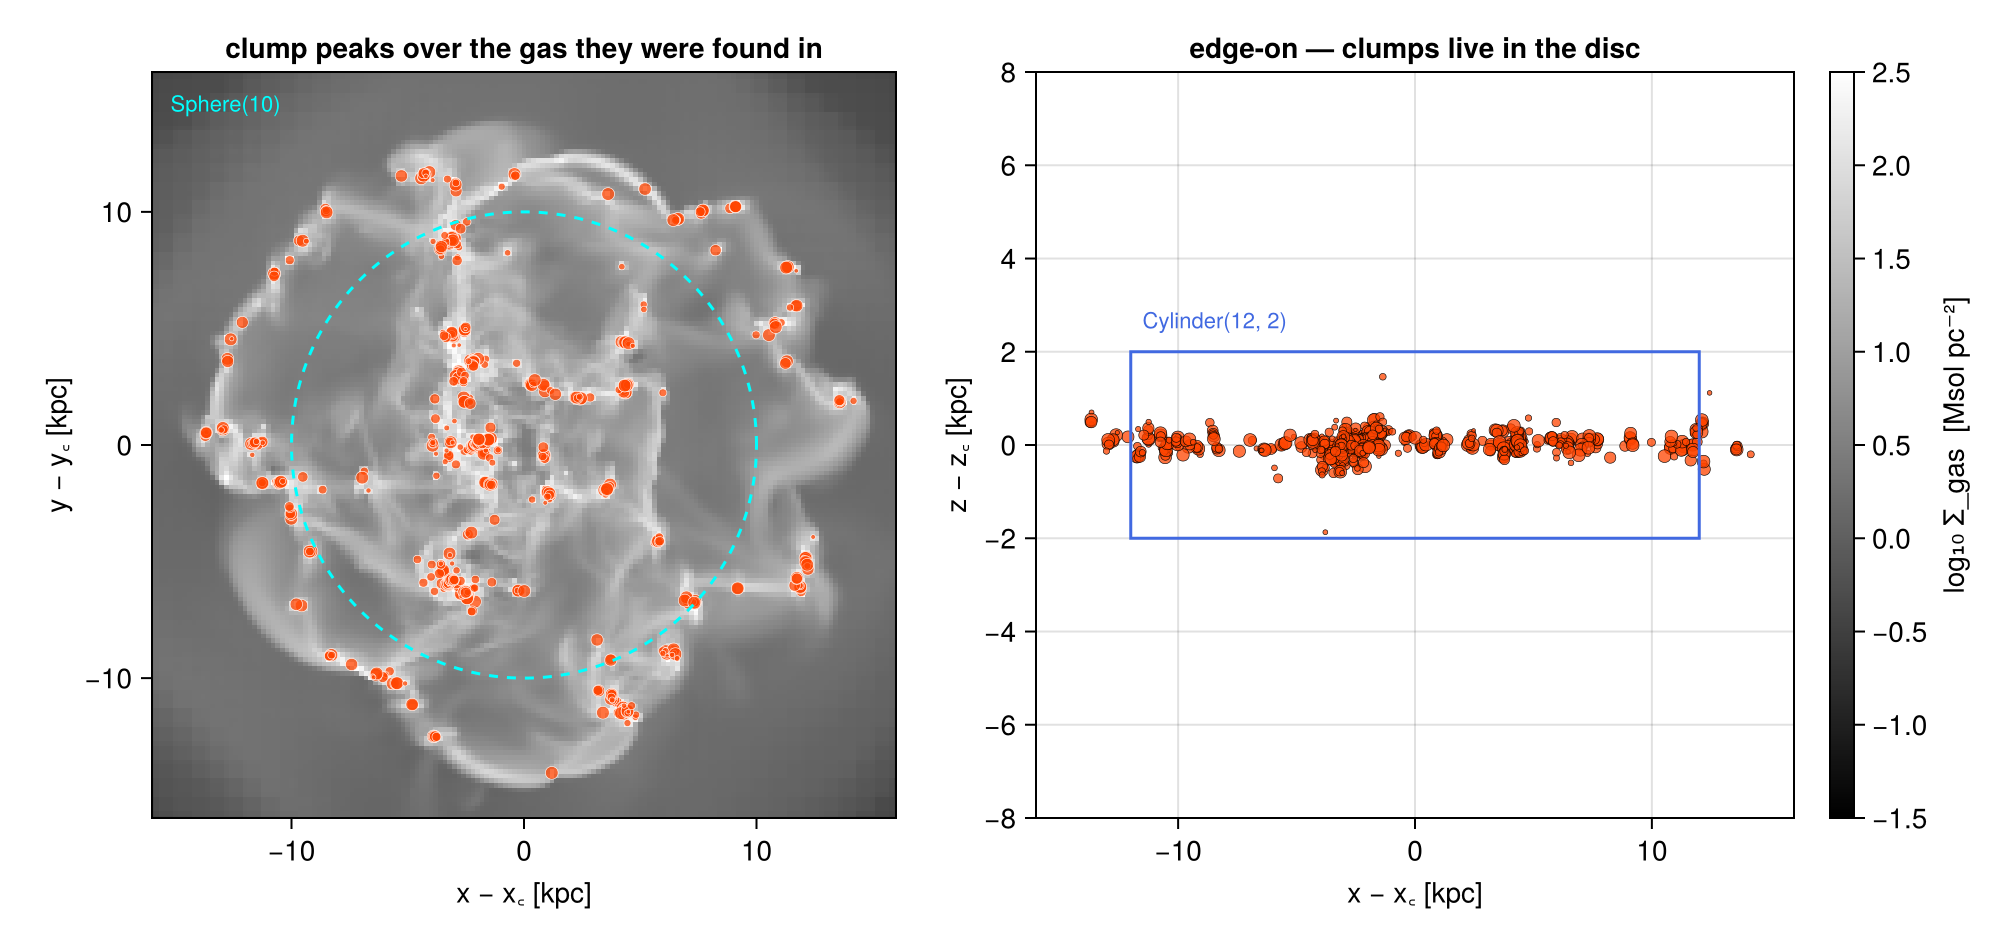

In [3]:
p_face = gproj(gas)
cx, cy, cz = peaks(clumps)


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(1000, 470))
ax1 = Axis(fig[1, 1], title="clump peaks over the gas they were found in",
           xlabel="x − x꜀ [kpc]", ylabel="y − y꜀ [kpc]")
show_sd!(ax1, p_face; decorate=true)
scatter!(ax1, cx, cy; markersize=msize(clumps), color=(:orangered, 0.75),
         strokewidth=0.3, strokecolor=:white)
arc!(ax1, Point2f(0, 0), 10., 0, 2π; color=:cyan, linewidth=1.5, linestyle=:dash)
text!(ax1, -15.2, 15.2; text="Sphere(10)", color=:cyan, fontsize=11,
      align=(:left, :top))
limits!(ax1, -16, 16, -16, 16)

ax2 = Axis(fig[1, 2], title="edge-on — clumps live in the disc",
           xlabel="x − x꜀ [kpc]", ylabel="z − z꜀ [kpc]")
scatter!(ax2, cx, cz; markersize=msize(clumps), color=(:orangered, 0.75),
         strokewidth=0.3, strokecolor=:black)
lines!(ax2, [-12., 12., 12., -12., -12.], [-2., -2., 2., 2., -2.];
       color=:royalblue, linewidth=1.5)
text!(ax2, -11.5, 2.4; text="Cylinder(12, 2)", color=:royalblue, fontsize=11)
limits!(ax2, -16, 16, -8, 8)
Colorbar(fig[1, 3]; colormap=:bone, colorrange=SDLIM, label="log₁₀ Σ_gas  [Msol pc⁻²]")
fig


Marker area scales with clump mass. They trace the dense gas, they are
confined to the disc, and — the point of the next two sections — they are
*objects*, not samples: a few hundred of them stand in for the entire
population of dense structures in this galaxy.


## 2. One Sphere, and an Exact Selection

Mechanically this is the particle case. `subregion` tests each peak against
the region and keeps whole rows; there is no `:fraction`, no `split`, and a
region together with its complement partitions the catalogue exactly.


In [4]:
sph   = Sphere(10.)                     # center=[:bc], range_unit=:kpc by default
c_in  = subregion(clumps, sph, verbose=false)
c_out = subregion(clumps, sph, inverse=true, verbose=false)

println("all clumps        : ", rpad(length(clumps.data), 7), round(msum(clumps, :Msol), sigdigits=7), " Msol")
println("peak inside  r<10 : ", rpad(length(c_in.data), 7),  round(msum(c_in, :Msol),  sigdigits=7))
println("peak outside r>10 : ", rpad(length(c_out.data), 7), round(msum(c_out, :Msol), sigdigits=7))
println()
println("count residual : ", length(c_in.data) + length(c_out.data) - length(clumps.data))
println("clump mass as a share of the gas inside r < 10 kpc : ",
        round(100 * msum(c_in, :Msol) / msum(subregion(gas, sph, verbose=false), :Msol), digits=2), " %")


all clumps        : 644    

1.374328e10 Msol
peak inside  r<10 : 400    9.640827e9
peak outside r>10 : 244    4.102454e9

count residual : 0
clump mass as a share of the gas inside r < 10 kpc : 

52.94 %


The counts close exactly, as they must for a membership test.

The last line is more interesting than it looks. The clumps in this sphere
hold **53 %** of its gas mass — this finder's density threshold is low enough
that the catalogue is not a sprinkling of rare peaks but half the inner
galaxy's gas, gathered into 400 objects. That is worth knowing before quoting
any clump statistic as "the dense gas".

It is still not a decomposition. The other 47 % is diffuse material that
belongs to no clump, so summing clump masses gives a *lower bound* on the gas
in a region, never an estimate of it — and no region operation changes that.
Ratios of the two (this one, or its radial profile) are the meaningful
statistic.


## 3. The Peak Is a Proxy: from a Number to a Bracket

Here is where a catalogue differs from a particle list.

A star particle *is* a point; putting it inside or outside a region is not an
approximation. A clump is not a point. It has an extent, and the catalogue
gives us enough to estimate it: mass and mean density imply a volume, and a
volume implies an effective radius,

$$r_\mathrm{eff} = \left(\frac{3}{4\pi}\frac{M_\mathrm{cl}}{\rho_\mathrm{av}}\right)^{1/3}.$$

That is a crude sphere-equivalent radius — real clumps are filamentary — but
it is enough to answer the question that matters: *how many of these objects
does a given boundary cut through?*


In [5]:
m_code = getvar(clumps, :mass)        # code units — only the ratio matters here
rho_av = getvar(clumps, :rho_av)
r_eff  = (3 .* (m_code ./ rho_av) ./ (4π)).^(1/3) .* kpc      # kpc

mass = getvar(clumps, :mass, :Msol)
d    = sqrt.(cx.^2 .+ cy.^2 .+ cz.^2)     # peak distance from the box centre, kpc
r_med = sort(r_eff)[cld(length(r_eff), 2)]

println("cells per clump : ", Int(minimum(getvar(clumps, :ncell))), " – ",
        Int(maximum(getvar(clumps, :ncell))))
println("effective radii : ", round(minimum(r_eff)*1e3, digits=1), " – ",
        round(maximum(r_eff)*1e3, digits=1), " pc   (median ",
        round(r_med*1e3, digits=1), " pc)")

# the Sphere(10) of §2: how many clumps does that boundary actually cut?
R = 10.0
straddling = count(abs.(d .- R) .< r_eff)
peak  = sum(mass[d .< R])
upper = sum(mass[d .- r_eff .< R])        # every clump that overlaps at all
lower = sum(mass[d .+ r_eff .< R])        # only clumps entirely inside
println()
println("clumps cut by the r = 10 kpc surface : ", straddling, " of ", length(d))
println("mass inside — lower / peak / upper   : ", round(lower, sigdigits=6), " / ",
        round(peak, sigdigits=6), " / ", round(upper, sigdigits=6), " Msol")
println("bracket width                        : ",
        round(100*(upper - lower)/peak, digits=4), " %")


cells per clump : 87

 – 12250
effective radii : 8.1 – 41.9 pc   (median 16.5 pc)



clumps cut by the r = 10 kpc surface : 1 of 644
mass inside — lower / peak / upper   : 9.59732e9 / 9.64083e9 / 9.64083e9 Msol
bracket width                        : 0.4512 %


For a 10 kpc sphere the answer is: one clump out of 644, and half a percent.
The clumps in this galaxy are tens of parsecs across, the region is ten
kiloparsecs, and its boundary passes almost entirely through space between
objects three orders of magnitude smaller than itself. The peak proxy is
exact for every practical purpose here, and this page is not an argument
against using it.

Note where even that half a percent comes from: a *single* object. With 644
rows in the catalogue and a mass function spanning three decades, one massive
clump on the boundary is worth more than the counting noise of a whole
annulus. Small catalogues are lumpy.

But the ambiguity is not a property of the catalogue alone — it is the ratio
of object size to *region* size. Shrink the region and it grows. The cleanest
way to see that is to keep one shape and sweep its scale: a midplane slab,
from a couple of kpc thick down to the size of a single clump.


slab |z| < 2.0    

 kpc :  bracket = 0.0 %
slab |z| < 0.5     kpc :  bracket = 0.45 %
slab |z| < 0.1     kpc :  bracket = 51.39 %
slab |z| < 0.02    kpc :  bracket = 153.13 %
slab |z| < 0.005   kpc :  bracket = 234.42 %


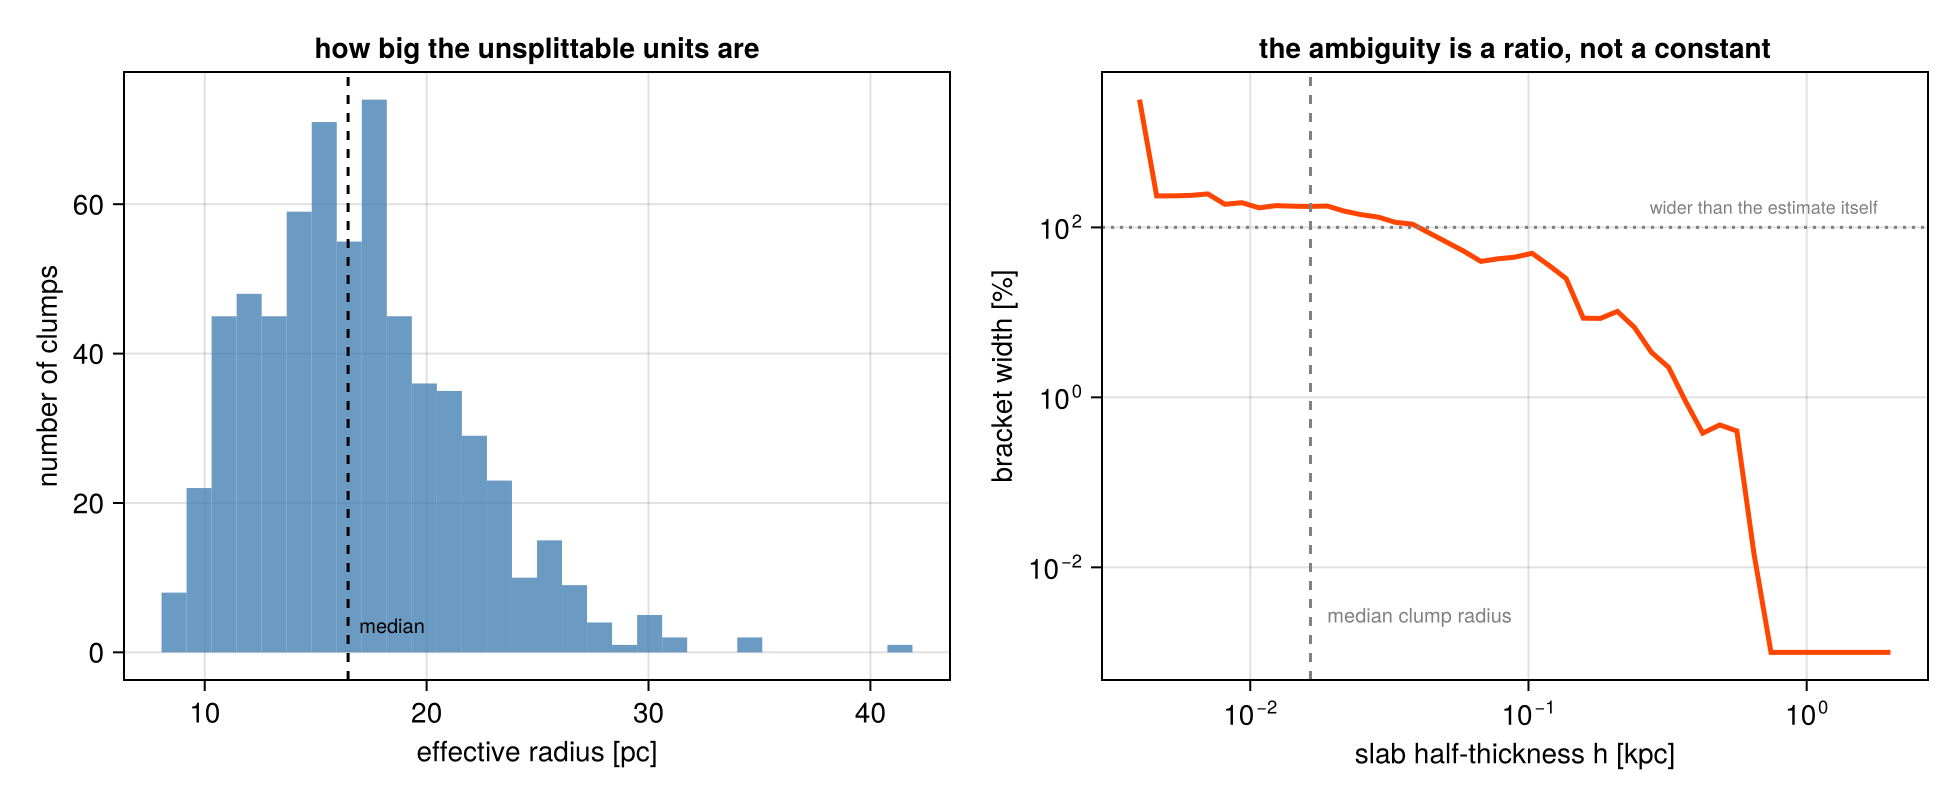

In [6]:
zc = cz                                    # peak height above the midplane, kpc

function slab_bracket(h)                   # |z| < h, three boundary conventions
    pk = sum(mass[abs.(zc) .< h])
    up = sum(mass[abs.(zc) .- r_eff .< h])
    lo = sum(mass[abs.(zc) .+ r_eff .< h])
    return pk > 0 ? 100 * (up - lo) / pk : NaN
end

hs = 10 .^ range(log10(0.004), log10(2.0); length=45)
br = slab_bracket.(hs)

for h in (2.0, 0.5, 0.1, 0.02, 0.005)
    println("slab |z| < ", rpad(h, 7), " kpc :  bracket = ",
            round(slab_bracket(h), digits=2), " %")
end


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(980, 400))
ax1 = Axis(fig[1, 1], xlabel="effective radius [pc]", ylabel="number of clumps",
           title="how big the unsplittable units are")
hist!(ax1, r_eff .* 1e3; bins=30, color=(:steelblue, 0.8))
vlines!(ax1, [r_med * 1e3]; color=:black, linestyle=:dash)
text!(ax1, r_med*1e3, 2; text="  median", align=(:left, :bottom), fontsize=10)

ax2 = Axis(fig[1, 2], xlabel="slab half-thickness h [kpc]", ylabel="bracket width [%]",
           xscale=log10, yscale=log10, title="the ambiguity is a ratio, not a constant")
lines!(ax2, hs, max.(br, 1e-3); color=:orangered, linewidth=2.5)
hlines!(ax2, [100.]; color=:grey, linestyle=:dot)
text!(ax2, 1.8, 130; text="wider than the estimate itself", color=:grey, fontsize=9,
      align=(:right, :bottom))
vlines!(ax2, [r_med]; color=:grey, linestyle=:dash)
text!(ax2, r_med*1.15, 2e-3; text="median clump radius", color=:grey, fontsize=10,
      align=(:left, :bottom))
fig


At the slab thicknesses this galaxy is normally sliced with the bracket is
negligible: 0 % at |z| < 2 kpc — no clump reaches that high — and 0.45 % at
|z| < 0.5 kpc. Follow the curve leftward and it climbs fast: 51 % at 100 pc,
and past 100 % below about 20 pc, where the bracket is wider than the estimate
it brackets. By the time the slab is as thin as a clump is wide, "the clump
mass in this slab" has stopped being a well-defined quantity at all.

Two things are worth taking from that.

First, the check is cheap. Two extra sums against `d ± r_eff` tell you whether
the region you are about to use is in the safe regime, and the answer is not
always obvious — a *thin* region can be geometrically large and still be
dominated by boundary effects.

Second, this ambiguity is a different kind of thing from the hydro page's
whole-cell excess. There, refinement shrinks it and fraction splitting removes
it outright. Here nothing in the catalogue can remove it, because the
information needed to split a clump — where inside it the mass sits — was
discarded when the finder wrote one row per object. The only ways out are to
keep the regions large compared with the clumps, or to go back to the gas and
do the measurement on cells.

A practical corollary: do not place a region boundary so that it deliberately
runs through the structures you are studying. If one has to fall there, quote
the bracket.


## 4. The Geometry Gallery

Every region value type applies to a clump catalogue, with the usual keywords:
`center`, `range_unit`, `inverse=true`, and `axis` to tilt a cylinder. The
grid-boundary keywords — `split`, `nsub`, `refine`, `refine_to` — have nothing
to act on and are absent.


Cuboid — a slab               603    

95.4 % of the clump mass
Cylinder(8, 2)                352    57.9 % of the clump mass
Sphere(6)                     249    37.8 % of the clump mass
SphericalShell(6, 10)         

151    32.3 % of the clump mass
CylindricalShell(6, 10, 2)    151    32.3 % of the clump mass
Cylinder(8, 2) tilted 40°     196    28.5 % of the clump mass


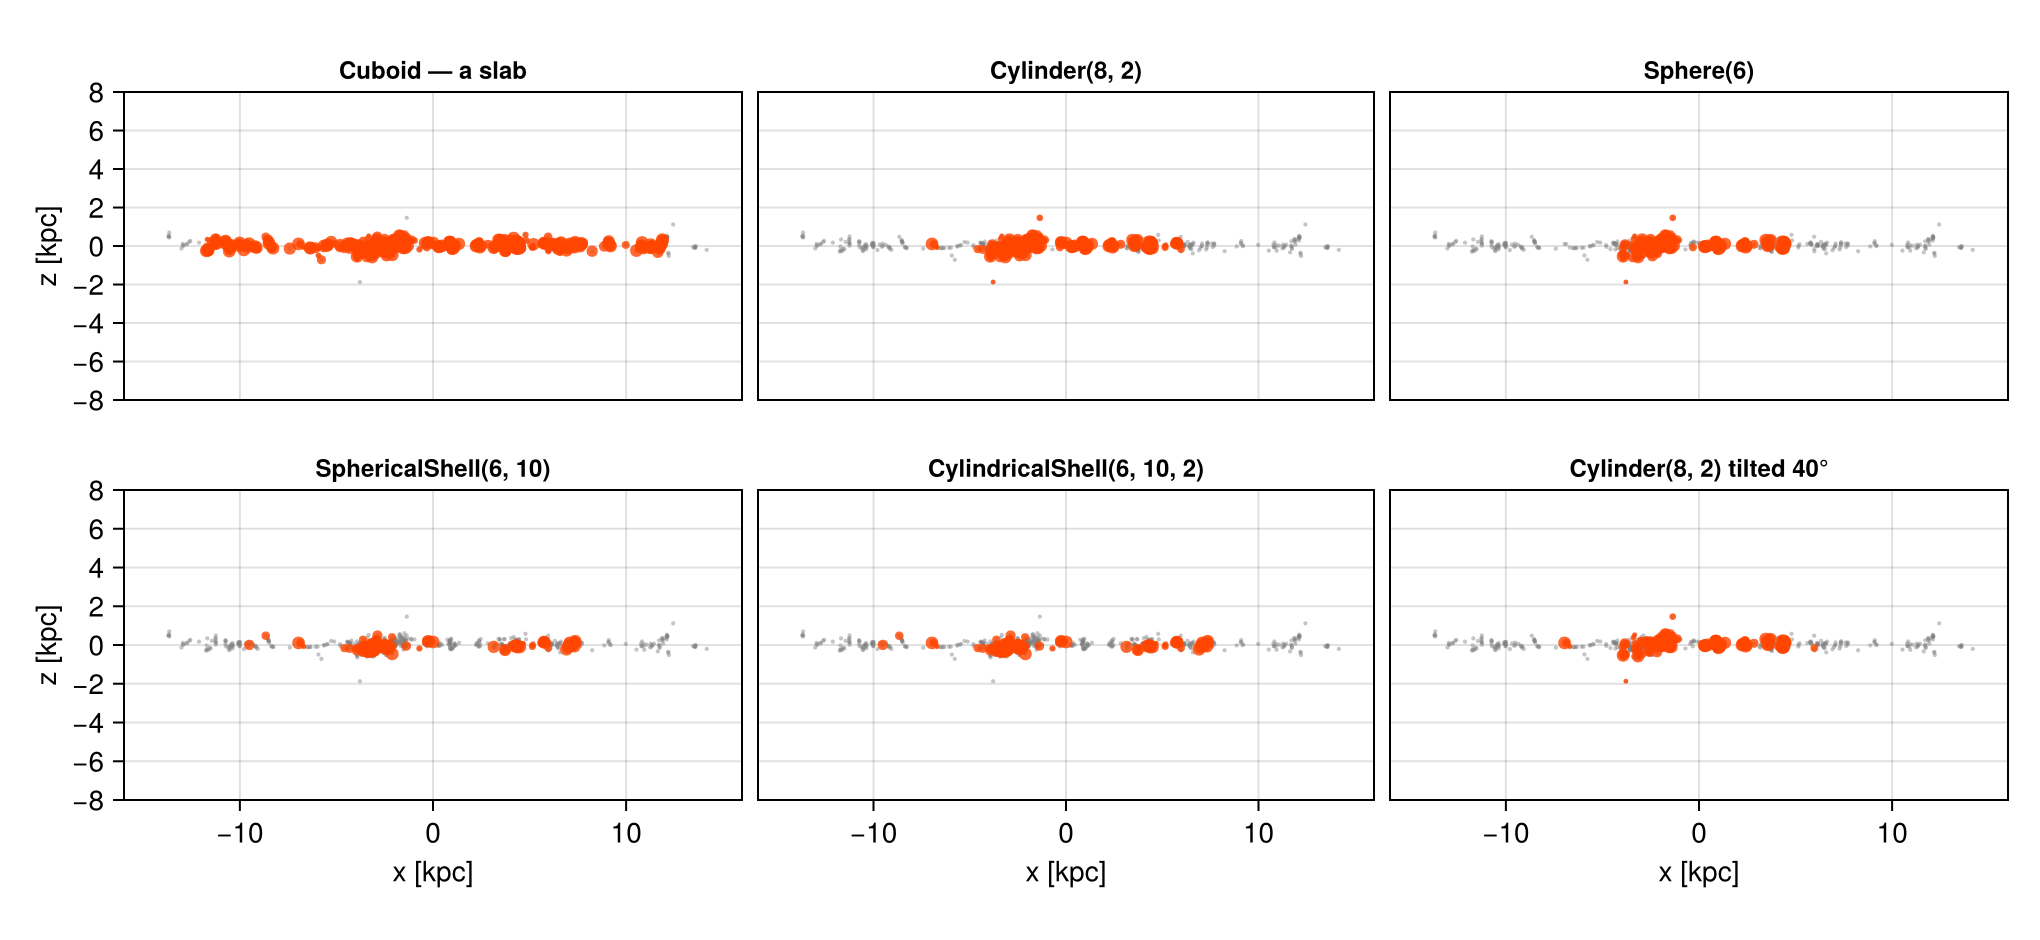

In [7]:
gallery = [
    ("Cuboid — a slab",            Cuboid(xrange=[-12, 12], yrange=[-12, 12], zrange=[-1, 1])),
    ("Cylinder(8, 2)",             Cylinder(8., 2.)),
    ("Sphere(6)",                  Sphere(6.)),
    ("SphericalShell(6, 10)",      SphericalShell(6., 10.)),
    ("CylindricalShell(6, 10, 2)", CylindricalShell(6., 10., 2.)),
    ("Cylinder(8, 2) tilted 40°",  Cylinder(8., 2.; axis=[0, sind(40), cosd(40)])),
]
for (name, reg) in gallery
    s = subregion(clumps, reg, verbose=false)
    println(rpad(name, 30), rpad(length(s.data), 7),
            round(100*msum(s, :Msol)/msum(clumps, :Msol), digits=1), " % of the clump mass")
end


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(1020, 470))
for (k, (name, reg)) in enumerate(gallery)
    s = subregion(clumps, reg, verbose=false)
    sx, sy, sz = peaks(s)
    row, col = fld(k-1, 3)+1, mod(k-1, 3)+1
    ax = Axis(fig[row, col], title=name, titlesize=12,
              xlabel=(row == 2 ? "x [kpc]" : ""), ylabel=(col == 1 ? "z [kpc]" : ""))
    scatter!(ax, cx, cz; markersize=3, color=(:grey, 0.45))
    scatter!(ax, sx, sz; markersize=msize(s), color=(:orangered, 0.8))
    limits!(ax, -16, 16, -8, 8); ax.aspect = DataAspect()
    row == 2 || hidexdecorations!(ax; grid=false)
    col == 1 || hideydecorations!(ax; grid=false)
end
rowgap!(fig.layout, 4); colgap!(fig.layout, 8)
fig


Grey is the whole catalogue, orange what the region kept, seen edge-on. With a
few hundred objects the panels double as a sanity check you cannot get from a
grid: you can *see* every selected item, and a region that has gone wrong is
obvious immediately.

The two shells are worth a second look — they select exactly the same clumps.
A spherical shell and a cylindrical shell of the same radii differ only off
the midplane, and this population is thin enough that there is nothing out
there to differ about. On the gas, the same two regions would enclose very
different volumes.


## 5. Composites and the `@region` Block

Boolean composition works as everywhere else — `∩` `∪` `\` `!`, or
`intersect` / `union` / `setdiff` — and `@region` keeps a composite readable by
hoisting the shared keywords out of the constructors.

(`∩` is typed `\cap`+TAB, `∪` is `\cup`+TAB; the named functions are always
available if you prefer.)


In [8]:
outer_disc = @region unit=:kpc center=[:bc] begin
    disc = Cylinder(12, 2)
    core = Cylinder(4, 2)
    disc \ core             # the star-forming annulus, nucleus excluded
end

c_ring = subregion(clumps, outer_disc, verbose=false)
c_disc = subregion(clumps, Cylinder(12., 2.), verbose=false)
c_core = subregion(clumps, Cylinder(4., 2.), verbose=false)

println("disc slab            : ", rpad(length(c_disc.data), 7), round(msum(c_disc, :Msol), sigdigits=6), " Msol")
println("  nucleus  r < 4     : ", rpad(length(c_core.data), 7), round(msum(c_core, :Msol), sigdigits=6))
println("  annulus 4 < r < 12 : ", rpad(length(c_ring.data), 7), round(msum(c_ring, :Msol), sigdigits=6))
println()
println("counts partition : ", length(c_core.data) + length(c_ring.data) == length(c_disc.data))
println("masses add       : ", msum(c_core, :Msol) + msum(c_ring, :Msol) ≈ msum(c_disc, :Msol))


disc slab            : 519    

1.14995e10 Msol
  nucleus  r < 4     : 169    3.16131e9
  annulus 4 < r < 12 : 350    8.33822e9

counts partition : true
masses add       : true


Both checks pass exactly, and for the same reason as on the particle page:
each clump is assigned to one side or the other, so a partition of the region
is a partition of the catalogue. This is the cheapest possible test that a
composite means what you think, and it costs one line.


## 6. Place *and* Property: Regions Meet Filters

A clump table is unusually rich in per-object properties, and `filterdata`
selects on any of them by value — mass, mean density, cell count, or the clump
finder's own `:relevance`. Geometric and property cuts compose in either
order.

`:relevance` is the clump finder's own significance measure — a peak-to-saddle
density contrast, large when a clump is clearly separated from its neighbours
and close to 1 when it is barely a distinct object. This run kept nothing
below 2, so filtering on it means asking for clumps *more* clearly separated
than the finder's own floor.

`AbovePercentile` is worth knowing about here: it thresholds at a percentile of
the data rather than at an absolute value, which is the right tool when you
want "the most massive tenth" of a catalogue whose mass scale you have not
looked at yet.


In [9]:
disc = subregion(clumps, Cylinder(12., 2.), verbose=false)

solid   = filterdata(disc, Above(:relevance, 3.0), verbose=false)   # well-separated peaks
massive = filterdata(disc, AbovePercentile(:mass, 90), verbose=false)  # top 10 % by mass
both    = filterdata(disc, Above(:relevance, 3.0),
                           AbovePercentile(:mass, 90), verbose=false)

println("disc slab               : ", rpad(length(disc.data), 7),
        round(msum(disc, :Msol), sigdigits=6), " Msol")
println("  relevance > 3         : ", rpad(length(solid.data), 7),
        round(msum(solid, :Msol), sigdigits=6))
println("  most massive 10 %     : ", rpad(length(massive.data), 7),
        round(msum(massive, :Msol), sigdigits=6))
println("  both conditions       : ", rpad(length(both.data), 7),
        round(msum(both, :Msol), sigdigits=6))
println()
# order does not matter
alt = subregion(filterdata(clumps, Above(:relevance, 3.0), verbose=false),
                Cylinder(12., 2.), verbose=false)
println("region∘filter == filter∘region : ", length(alt.data) == length(solid.data))


disc slab               : 519    

1.14995e10 Msol
  relevance > 3         : 439    1.08897e10
  most massive 10 %     : 52     6.81601e9
  both conditions       : 50     6.69392e9

region∘filter == filter∘region : true


Multiple conditions passed to one `filterdata` call are ANDed; `&`, `|`, and
`!` compose them explicitly, and the
[Masking & Filtering page](05_multi_Masking_Filtering.md) covers the full
vocabulary. The important structural point is the last line: geometry and
property are independent, so the order you apply them in cannot change the
answer.


## 7. Profiles, and Why the Counts Are the Limit

A stack of `CylindricalShell` annuli turns the catalogue into a radial
profile. With a few hundred objects in total, though, the honest constraint is
not the geometry — it is how many clumps land in each ring.


annulus [kpc]   N     M [Msol]    1/√N
--------------------------------------------
0.5 – 1.5       16    1.907e8     25.0 %
1.5 – 2.5       84    2.176e9     11.0 %
2.5 – 3.5       48    6.661e8     14.0 %
3.5 – 4.5       58    1.257e9     13.0 %
4.5 – 5.5       20    4.817e8     22.0 %
5.5 – 6.5       54    1.288e9     14.0 %
6.5 – 7.5       70    1.888e9     12.0 %
7.5 – 8.5       4     1.685e7     50.0 %
8.5 – 9.5       26    1.355e9     20.0 %
9.5 – 10.5      36    4.822e8     17.0 %
10.5 – 11.5     53    8.519e8     14.0 %
11.5 – 12.5     94    1.878e9     10.0 %
12.5 – 13.5     61    9.12e8      13.0 %
13.5 – 14.5     20    3.004e8     22.0 %
14.5 – 15.5     0     0.0         —


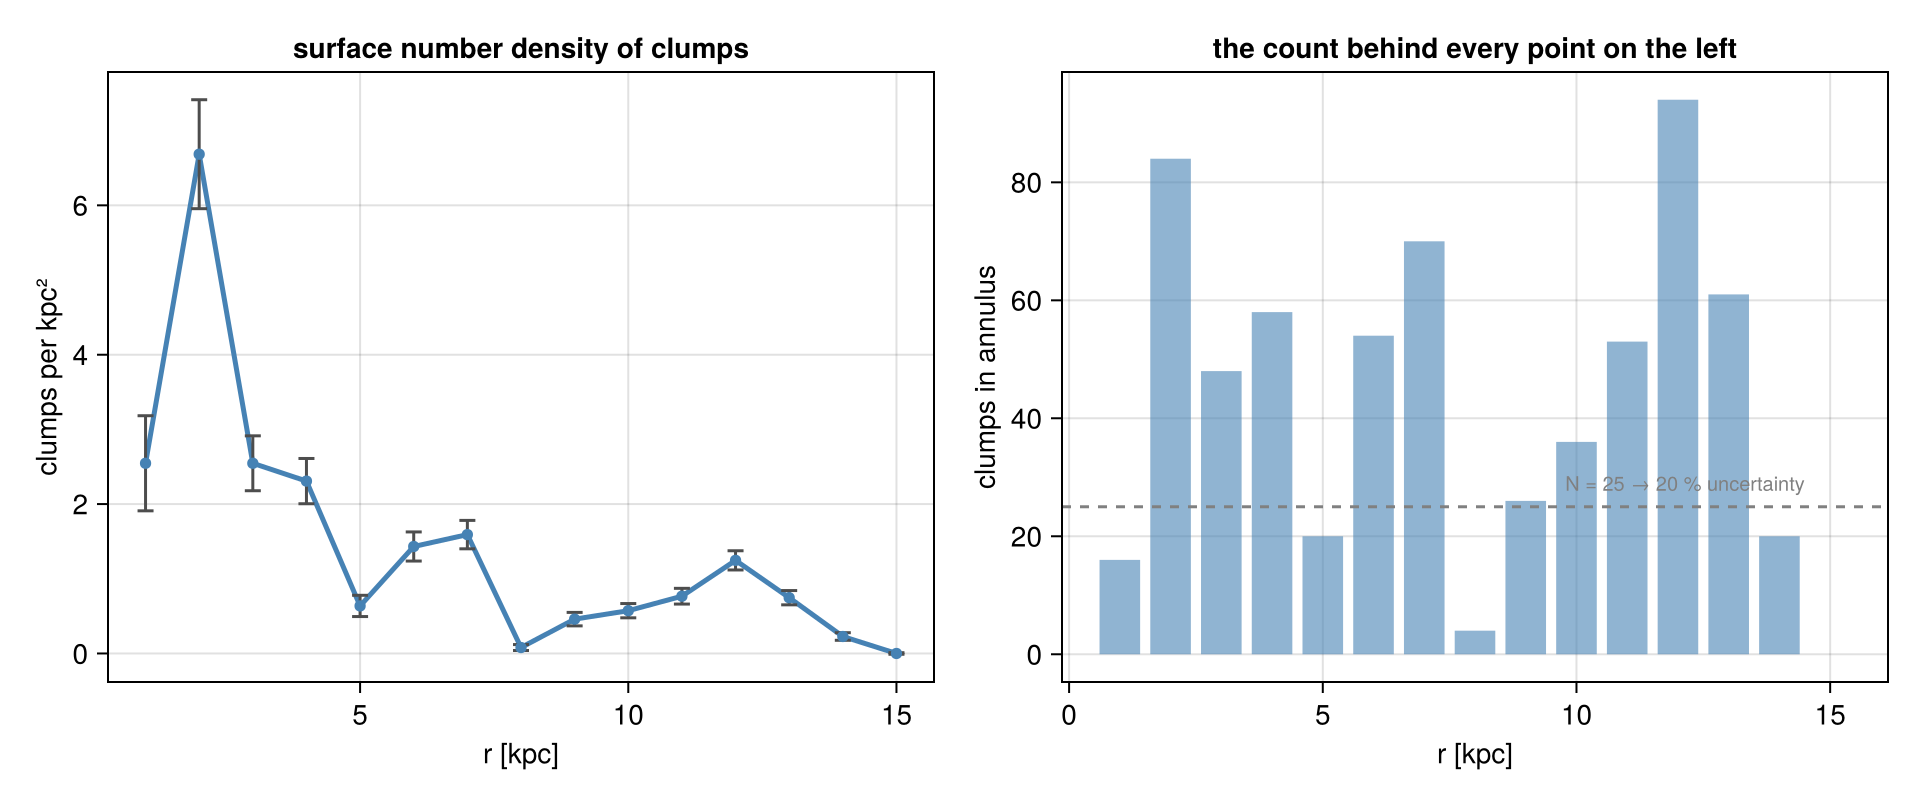

In [10]:
r_ann = collect(1.0:1.0:15.0)
n_cl, m_cl, area = Int[], Float64[], Float64[]
for r in r_ann
    a = subregion(clumps, CylindricalShell(r-0.5, r+0.5, 2.), verbose=false)
    push!(n_cl, length(a.data))
    push!(m_cl, length(a.data) == 0 ? 0.0 : msum(a, :Msol))
    push!(area, π*((r+0.5)^2 - (r-0.5)^2))          # kpc²
end

println(rpad("annulus [kpc]", 16), rpad("N", 6), rpad("M [Msol]", 12), "1/√N")
println("-"^44)
for (r, n, m) in zip(r_ann, n_cl, m_cl)
    println(rpad(string(r-0.5, " – ", r+0.5), 16), rpad(n, 6),
            rpad(round(m, sigdigits=4), 12),
            n == 0 ? "—" : string(round(100/sqrt(n), digits=0), " %"))
end


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(960, 400))
ax1 = Axis(fig[1, 1], xlabel="r [kpc]", ylabel="clumps per kpc²",
           title="surface number density of clumps")
lines!(ax1, r_ann, n_cl ./ area; color=:steelblue, linewidth=2.5)
errorbars!(ax1, r_ann, n_cl ./ area, sqrt.(max.(n_cl, 1)) ./ area;
           whiskerwidth=8, color=:grey30)
scatter!(ax1, r_ann, n_cl ./ area; color=:steelblue, markersize=8)

ax2 = Axis(fig[1, 2], xlabel="r [kpc]", ylabel="clumps in annulus",
           title="the count behind every point on the left")
barplot!(ax2, r_ann, n_cl; color=(:steelblue, 0.6))
hlines!(ax2, [25.]; color=:grey, linestyle=:dash)
text!(ax2, 14.5, 27; text="N = 25 → 20 % uncertainty", color=:grey, fontsize=10,
      align=(:right, :bottom))
fig


The left panel looks like a measured profile. The right panel is what it is
made of: a dozen or two objects per ring, sometimes fewer. The error bars are
$\sqrt{N}$, and outside the star-forming disc they are the entire story.

This is the same lesson as the [particle page's](03_particles_Get_Subregions.md)
§3, arriving sooner. A clump catalogue is a small sample by construction — the
finder returns hundreds of objects where the grid has millions of cells — so
it reaches the counting limit at radii where a particle or cell profile is
still perfectly smooth. Bin wide, quote $N$, and resist reading structure into
rings holding five objects.


## 8. Reference: the Classic Symbol API

The symbol interface works on clump data unchanged, testing the same peak
positions.

| Value type | Classic call |
|:--|:--|
| `Cuboid(xrange=…, yrange=…, zrange=…)` | `subregion(clumps, :cuboid; xrange=…, …)` |
| `Sphere(R)` | `subregion(clumps, :sphere; radius=R)` |
| `Cylinder(R, H)` | `subregion(clumps, :cylinder; radius=R, height=H)` (z-axis only) |
| `SphericalShell(rin, rout)` | `shellregion(clumps, :sphere; radius=[rin, rout])` |
| `CylindricalShell(rin, rout, H)` | `shellregion(clumps, :cylinder; radius=[rin, rout], height=H)` |

Shared keywords: `center`, `range_unit`, `inverse=true`. As on the particle
side, `cell` and `split` have no meaning for point-like rows, so the classic
and value-type selections agree exactly.

`getpositions(clumps, :kpc, center=[:boxcenter])` returns the three peak
coordinate arrays in one call, and `getextent(clumps, :kpc, center=[:boxcenter])`
the coordinate ranges of the loaded object — for a catalogue read from the
whole box, that is the box itself. Both are convenience accessors, handy for
setting plot limits.


In [11]:
classic = subregion(clumps, :sphere; radius=10., center=[:bc], range_unit=:kpc, verbose=false)
value_t = subregion(clumps, Sphere(10.), verbose=false)

println("classic :sphere   : ", rpad(length(classic.data), 7), round(msum(classic, :Msol), sigdigits=8))
println("value-type Sphere : ", rpad(length(value_t.data), 7), round(msum(value_t, :Msol), sigdigits=8))
println("identical         : ", length(classic.data) == length(value_t.data) &&
                                msum(classic, :Msol) == msum(value_t, :Msol))

rx, ry, rz = getextent(clumps, :kpc, center=[:boxcenter])
println()
println("catalogue extent  : x ", round.(rx, digits=2), "  y ", round.(ry, digits=2),
        "  z ", round.(rz, digits=2), " kpc")


classic :sphere   : 400    

9.6408271e9
value-type Sphere : 400    9.6408271e9
identical         : true

catalogue extent  : x (-24.0, 24.0)  y (-24.0, 24.0)  z (-24.0, 24.0) kpc


## 9. Practical Guidance

**The selection is exact; the interpretation is not.** `subregion` on a
catalogue is a clean membership test on peak positions. "The clump mass inside
this region" is a different claim, and it carries the bracket of §3 whenever
the boundary passes through clump-sized structures.

**Keep boundaries away from the objects.** Regions much larger than the
typical clump make the bracket negligible. Regions comparable to a clump make
it dominant — and at that point the question probably belongs on the gas, not
on the catalogue.

**Clumps are peaks, not a decomposition.** Their masses do not sum to the gas
mass of a region (§2). A ratio of the two is a meaningful statistic; treating
the catalogue as a partition of the gas is not.

**Counts run out fast.** Hundreds of rows, not millions. Every profile point
needs its $N$ quoted, and $\sqrt{N}$ is usually the largest error in the
figure (§7).

**Filter on the finder's own quality measures.** `:relevance` and `:ncell`
exist to let you discard marginal detections; applying a region to an
unfiltered catalogue silently includes them (§6).


## Summary

- A clump catalogue is a table of objects located by their density peaks;
  `subregion` is a membership test on those peaks, with no fractions and no
  `split` — partitions close exactly (§2, §5).
- Because a clump is extended but recorded as a point, a boundary through
  clumps turns a mass into a *bracket*. Mass and mean density give an
  effective radius (tens of pc here) that makes the bracket measurable: at
  kpc-scale regions it is a fraction of a percent, at clump-scale regions it
  is everything, and nothing in the catalogue can narrow it (§3).
- All region value types, boolean composition, `@region`, tilted axes and
  `inverse=true` behave as on every other page (§4, §5), and property filters
  compose with regions in either order (§6).
- With a few hundred objects, counting noise arrives early: profiles are
  limited by $N$ per bin, not by the geometry (§7).

**Continue with:**

- [Hydro sub-regions](03_hydro_Get_Subregions.md) — where the boundary
  ambiguity *can* be removed, by splitting cells on volume fraction.
- [Particle sub-regions](03_particles_Get_Subregions.md) — genuinely
  point-like data, and what limits it instead.
- [Gravity sub-regions](03_gravity_Get_Subregions.md) — the same regions on
  the force field.
- [Masking & Filtering](05_multi_Masking_Filtering.md) — the value-space
  counterpart of these selections.
